In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Processing: 26052026
  AOD shape: (122, 118)
  AI shape: (122, 118)
  TEMP shape: (122, 118)
  RH500 shape: (122, 118)
  RH850 shape: (122, 118)
  PRESSURE shape: (122, 118)
  WS shape: (122, 118)
  WD shape: (122, 118)
Processing: 27052026
  AOD shape: (122, 118)
  AI shape: (122, 118)
  TEMP shape: (122, 118)
  RH500 shape: (122, 118)
  RH850 shape: (122, 118)
  PRESSURE shape: (122, 118)
  WS shape: (122, 118)
  WD shape: (122, 118)
Processing: 28052026
  AOD shape: (122, 118)
  AI shape: (122, 118)
  TEMP shape: (122, 118)
  RH500 shape: (122, 118)
  RH850 shape: (122, 118)
  PRESSURE shape: (122, 118)
  WS shape: (122, 118)
  WD shape: (122, 118)
Processing: 29052026
  AOD shape: (122, 118)
  AI shape: (122, 118)
  TEMP shape: (122, 118)
  RH500 shape: (122, 118)
  RH850 shape: (122, 118)
  PRESSURE shape: (122, 118)
  WS shape: (122, 118)
  WD shape: (122, 118)
Processing: 30052026
  AOD shape: (122, 118)
  AI shape: (122, 118)
  TEMP shape: (122, 118)
  RH500 shape: (122, 118)
 

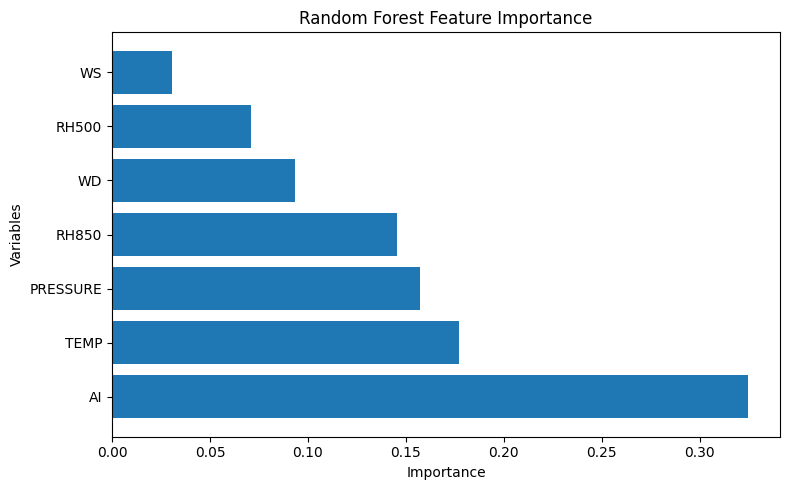

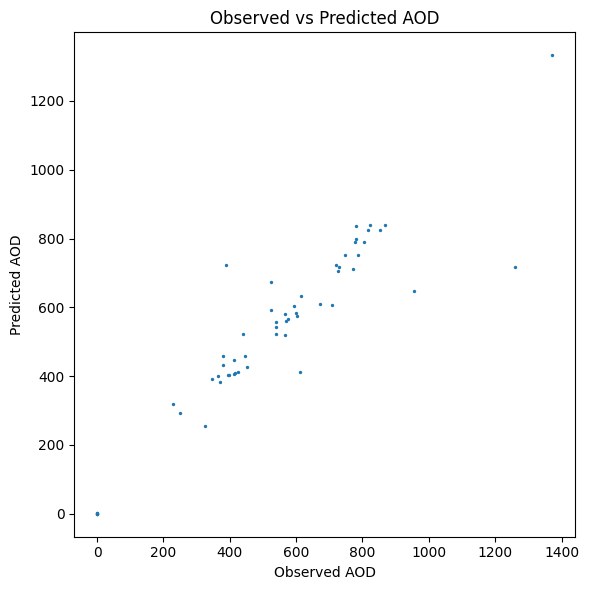

Finished Successfully


In [17]:
import os
import rasterio
from rasterio.warp import reproject, Resampling
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


root = r"/content/drive/My Drive/Dust_ML"

dates = [
    '26052026',
    '27052026',
    '28052026',
    '29052026',
    '30052026',
    '31052026',
    '01062026',
    '02062026',
    '03062026'
]

all_data = []

geotransform = None
target_crs = None
target_height = None
target_width = None


for date in dates:

    print("Processing:", date)

    aod_file = os.path.join(root,'AOD',f'MODIS_AOD_{date}.tif')
    ai_file = os.path.join(root,'AI',f'S5P_AER_AI_{date}.tif')
    temp_file = os.path.join(root,'Temperature',f'Temperature_2m_{date}.tif')
    rh500_file = os.path.join(root,'RH500',f'RH500_{date}.tif')
    rh850_file = os.path.join(root,'RH850',f'RH850_{date}.tif')
    pressure_file = os.path.join(root,'Pressure',f'Surface_Pressure_{date}.tif')
    ws_file = os.path.join(root,'WindSpeed',f'Wind_Speed_{date}.tif')
    wd_file = os.path.join(root,'WindDirection',f'Wind_Direction_{date}.tif')

    with rasterio.open(temp_file) as src_temp:
        target_crs = src_temp.crs
        geotransform = src_temp.transform
        target_width = src_temp.width
        target_height = src_temp.height
        temp = src_temp.read(1)

    def reproject_and_read(source_file, target_crs, target_transform, target_shape):
        with rasterio.open(source_file) as src:
            source_crs = src.crs
            source_transform = src.transform
            source_data = src.read(1)

            destination_data = np.empty(target_shape, dtype=source_data.dtype)

            reproject(
                source_data,
                destination_data,
                src_transform=source_transform,
                src_crs=source_crs,
                dst_transform=target_transform,
                dst_crs=target_crs,
                resampling=Resampling.bilinear,
                num_threads=4
            )
            return destination_data

    aod = reproject_and_read(aod_file, target_crs, geotransform, (target_height, target_width))
    ai = reproject_and_read(ai_file, target_crs, geotransform, (target_height, target_width))
    rh500 = reproject_and_read(rh500_file, target_crs, geotransform, (target_height, target_width))
    rh850 = reproject_and_read(rh850_file, target_crs, geotransform, (target_height, target_width))
    pressure = reproject_and_read(pressure_file, target_crs, geotransform, (target_height, target_width))
    ws = reproject_and_read(ws_file, target_crs, geotransform, (target_height, target_width))
    wd = reproject_and_read(wd_file, target_crs, geotransform, (target_height, target_width))

    print(f"  AOD shape: {aod.shape}")
    print(f"  AI shape: {ai.shape}")
    print(f"  TEMP shape: {temp.shape}")
    print(f"  RH500 shape: {rh500.shape}")
    print(f"  RH850 shape: {rh850.shape}")
    print(f"  PRESSURE shape: {pressure.shape}")
    print(f"  WS shape: {ws.shape}")
    print(f"  WD shape: {wd.shape}")

    df = pd.DataFrame({
        'AOD': aod.flatten(),
        'AI': ai.flatten(),
        'TEMP': temp.flatten(),
        'RH500': rh500.flatten(),
        'RH850': rh850.flatten(),
        'PRESSURE': pressure.flatten(),
        'WS': ws.flatten(),
        'WD': wd.flatten()
    })

    all_data.append(df)


data = pd.concat(all_data, ignore_index=True)

print("Total Samples:", len(data))


data.replace([-9999,-32768,np.inf,-np.inf], np.nan, inplace=True)

data.dropna(inplace=True)

print("After Cleaning:", len(data))

X = data[
[
'AI',
'TEMP',
'RH500',
'RH850',
'PRESSURE',
'WS',
'WD'
]
]

y = data['AOD']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.10,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\nModel Results (Full Data)")
print("R² =", round(r2,3))
print("RMSE =", round(rmse,3))
print("MAE =", round(mae,3))

importance = pd.DataFrame({
    'Variable': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("\nFeature Importance")
print(importance)

importance.to_csv(
    'Feature_Importance.csv',
    index=False
)

plt.figure(figsize=(8,5))

plt.barh(
    importance['Variable'],
    importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Variables')
plt.title('Random Forest Feature Importance')

plt.tight_layout()

plt.savefig(
    'Feature_Importance.png',
    dpi=300
)

plt.show()

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred,
    s=2
)

plt.xlabel('Observed AOD')
plt.ylabel('Predicted AOD')
plt.title('Observed vs Predicted AOD')

plt.tight_layout()

plt.savefig(
    'Observed_vs_Predicted.png',
    dpi=300
)

plt.show()

print("Finished Successfully")